# Exercise 2


## Supervised Learning- Classification Models

---

## Overview

In this exercise we will build a Decision Tree classifier to predict next-day stock returns.

---


In [1]:
import sys
import os

# Manually set the path relative to the py file's location that you want to import
func_lib_path = os.path.abspath(os.path.join(os.getcwd(), '../../'))# Add the path to sys.path
sys.path.append(func_lib_path)

# Now you can import func_lib
import func_lib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

In [2]:
# Retrieve historical price data.
# - Use the 'createHistPrices()' function from 'func_lib' to get historical price data.
# - Assign the result to the variable 'historical_prices'.

historical_prices = func_lib.create_hist_prices()

# Define the list of momentum periods.
list_of_momentums = [1, 5, 15, 20]

# Compute returns based on historical prices and momentum periods.
total_returns = func_lib.compute_returns(historical_prices, list_of_momentums)

# Remove any rows with missing values from the returns data.
total_returns.dropna(inplace=True)

[*********************100%%**********************]  501 of 501 completed

1 Failed download:
['SW']: YFChartError("%ticker%: Data doesn't exist for startDate = 946702800, endDate = 1714536000")


In [3]:
# Convert 'F_1_d_returns' to binary values based on whether they are positive or not.
total_returns['F_1_d_returns_Ind'] = total_returns['F_1_d_returns'].apply(lambda x: 1 if x > 0 else 0)
# Display the updated DataFrame.
total_returns.head()

F_1_d_returns  1_d_returns ...

In [4]:
# Determine the split index for 70% of the dates.
unique_dates = total_returns.index.get_level_values('Date').unique()
split_date = unique_dates[int(0.7 * len(unique_dates))]
print(split_date)

2017-01-20 00:00:00


In [5]:
# Create the training set: all data before the split date.
train_data = total_returns.loc[total_returns.index.get_level_values('Date') < split_date]

# Create the testing set: all data from the split date onwards.
test_data  = total_returns.loc[total_returns.index.get_level_values('Date') >= split_date]

In [6]:
# Extract the target variable for testing.
total_returns = test_data['F_1_d_returns']

In [7]:
# Define the features and target variables.
features = ['1_d_returns', '5_d_returns', '15_d_returns', '20_d_returns']
target   = ['F_1_d_returns_Ind']

# Split the data into training and testing sets.
X_train = train_data[features]
X_test  = test_data[features]
y_train = train_data[target]
y_test  = test_data[target]

In [8]:
# Standardize the features.
scaler = StandardScaler()

# Scale the training features
X_train_scaled = scaler.fit_transform(X_train)
# Scale the testing features
X_test_scaled  = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  index=X_test.index,  columns=features)

In [9]:
# Initialize and train a Decision Tree classifier.
# - Create an instance of the DecisionTreeClassifier class.
# - Fit the model to the scaled training data and the target values.

model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [10]:
# Define the model name.
model_name = 'DecTree'

# Make predictions using the trained Decision Tree model.
y_pred = model.predict(X_test_scaled)
y_pred_df = pd.DataFrame(y_pred, index=X_test_scaled.index)

# Rename the column in the predictions DataFrame.
y_pred_df.rename(columns={0: model_name}, inplace=True)

y_test_df = pd.DataFrame(total_returns)
y_test_and_pred = y_test_df.join(y_pred_df)

In [11]:
# Define a trading strategy based on Decision Tree predictions.
# - If the predicted value is greater than 0, return 1 (Go long).
# - Otherwise, return 0 (Do nothing).

def trading_strategy(y_pred):
    if y_pred > 0:
        return 1  # Go long
    else:
        return 0  # Do nothing

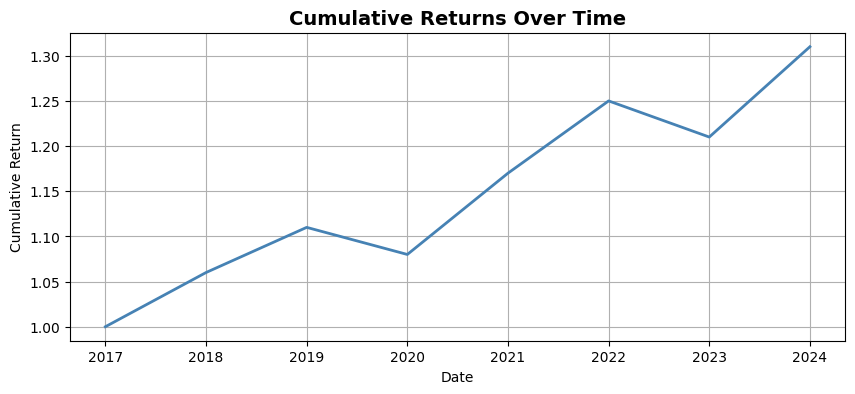

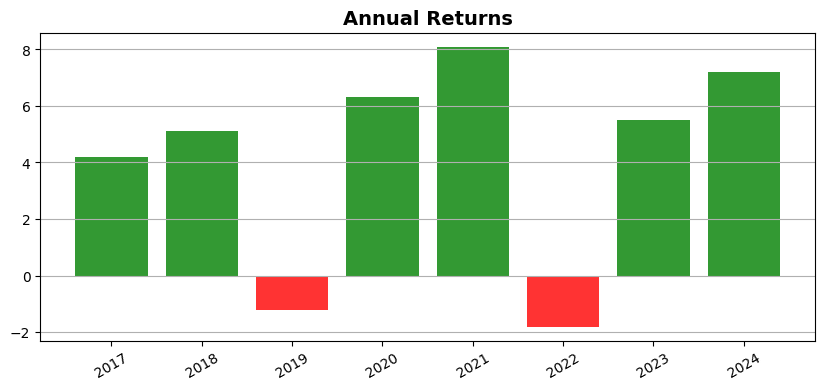

The CAGR is: 5.82%
Sharpe Ratio of Strategy: 0.47


In [12]:
# Compute performance metrics based on the predictions and actual returns.
cum_returns, calendar_returns = func_lib.compute_BM_Perf(y_test_and_pred)

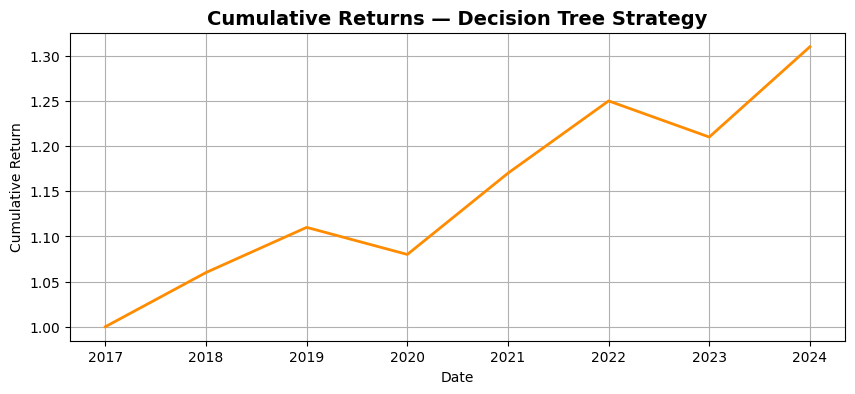

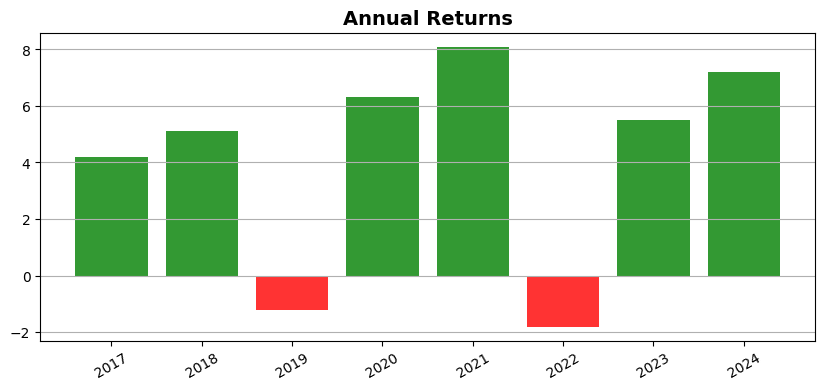

The CAGR is: 4.27%
Sharpe Ratio of Strategy: 0.38


In [13]:
# Compute strategy performance metrics.
cum_returns, calendar_returns = func_lib.compute_strat_perf(y_test_and_pred, cum_returns, calendar_returns, trading_strategy, model_name)